In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.simulation import ChiralTwin


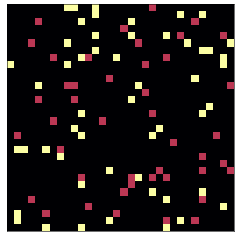

In [8]:
# Good initial condition
SIZE = (32, 32)
achiral_majority = np.random.choice([0, 1, 2], size=SIZE, p=[0.90, 0.05, 0.05])

plt.figure(figsize=(6, 6), dpi=50)
plt.imshow(achiral_majority, cmap='inferno', vmax=2)
plt.xticks([])
plt.yticks([])
plt.show()

In [9]:
config = {

    'simulation': {
        'total_steps': 250,
        'boundary_condition': 'periodic'
    },
    'probs': {
        'p_neutral': 0.1,
        'p_chiral': 0.1,
        'p_copy': 0.8
    },
    'chaos': {
        'seed': 42,
        'mode': 'constant',

        'constant': {
            'epsilon': 1.0
        },

        'pulse': {
            'start_step': 30,
            'end_step': 60,
            'magnitude': 0.5
        },

        'linear_increase': {
            'start_epsilon': 0.0,
            'end_epsilon': 1.0
        }
    }
}

In [10]:
twin                = ChiralTwin(achiral_majority, config = config)
list0, list1, list2 = twin.timeEvolution()

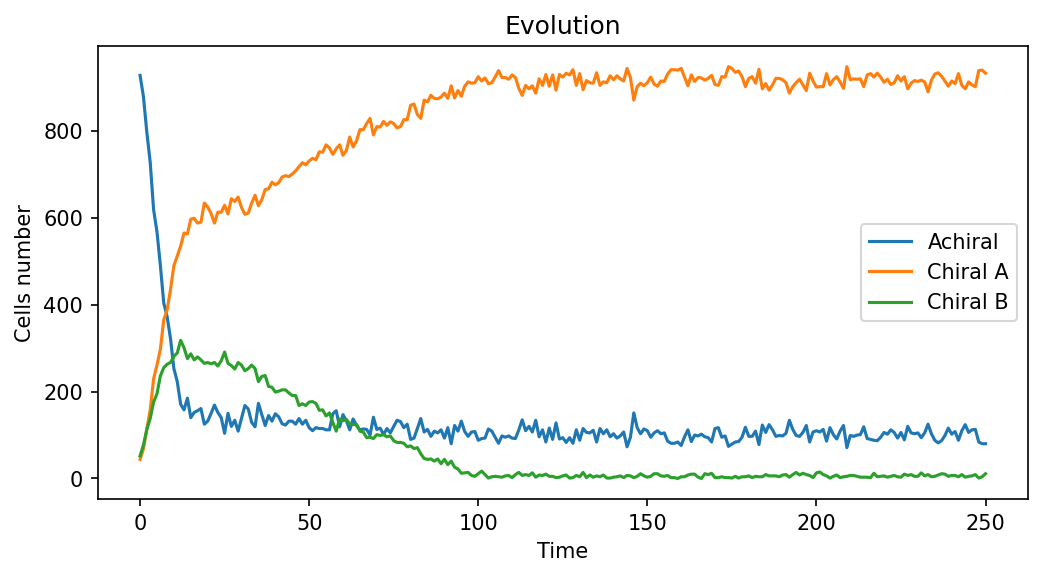

In [11]:
plt.figure(figsize=(8,4), dpi=150)
plt.plot(list0, label='Achiral')
plt.plot(list1, label='Chiral A')
plt.plot(list2, label='Chiral B')
plt.xlabel('Time')
plt.ylabel('Cells number')
plt.title('Evolution')
# plt.ylim(0)
plt.legend()
plt.show()

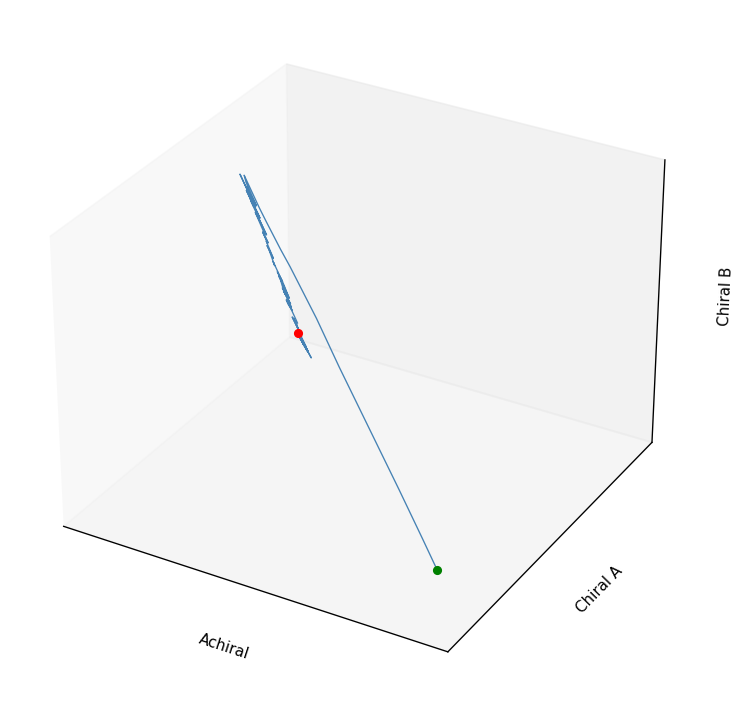

In [12]:
# Phase space (3D)
fig = plt.figure(figsize=(6, 6), dpi=120)
ax  = fig.add_subplot(111, projection='3d')

ax.plot(list0, list1, list2, lw=0.8, color='steelblue')
ax.scatter(list0[0],  list1[0],  list2[0],  color='green', s=20, zorder=5)  # start
ax.scatter(list0[-1], list1[-1], list2[-1], color='red',   s=20, zorder=5)  # end

ax.set_xlabel('Achiral',  fontsize=9)
ax.set_ylabel('Chiral A', fontsize=9)
ax.set_zlabel('Chiral B', fontsize=9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.tight_layout()
plt.show()
